# Titanic - Data Cleaning

The aim of this little exercise is to explore this Titanic dataset and just prepare it for a machine learning application. Firstly, we will need to check if the target column (person survived the shipwreck or not) is balanced between the two classes. Then we'll try to deal with missing data, if we find any.

In [41]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [5]:
df=pd.read_csv("tested.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [6]:
df.shape

(418, 12)

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [9]:
df['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [10]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    63.636364
1    36.363636
Name: proportion, dtype: float64

Considering that 0 = no, 1 = yes, we can state that 36.3% of the people on the Titanic survived. This number is sufficient to indicate that the occurrence of the class is not rare, so we can say that the dataframe is quite balanced.

In [11]:
df.count()

PassengerId    418
Survived       418
Pclass         418
Name           418
Sex            418
Age            332
SibSp          418
Parch          418
Ticket         418
Fare           417
Cabin           91
Embarked       418
dtype: int64

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

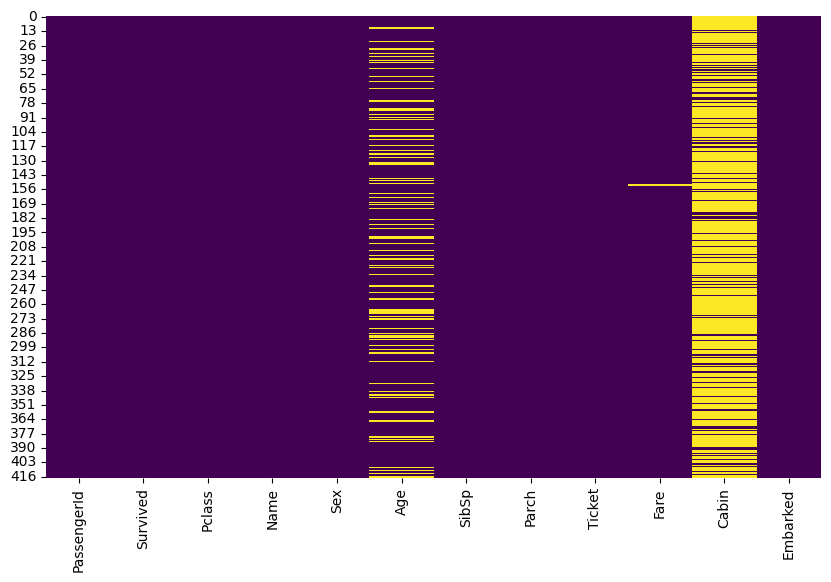

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

Moving on to missing data, we have some problems in three fields: Age, Fare and Cabin.

Fare is missing just one value, so we could input it with median without losing too much in variance terms.

In [14]:
df['Fare'].fillna(df['Fare'].median(), inplace=True)

C:\Users\elena\AppData\Local\Temp\ipykernel_20324\309285478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(), inplace=True)


In [23]:
df['Cabin'].value_counts()

Cabin
B57 B59 B63 B66    3
B45                2
C23 C25 C27        2
C78                2
C31                2
                  ..
B41                1
C7                 1
D40                1
D38                1
C105               1
Name: count, Length: 76, dtype: int64

In [31]:
df.sort_values('Cabin').head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
208,1100,1,1,"Rosenbaum, Miss. Edith Louise",female,33.0,0,0,PC 17613,27.7208,A11,C
331,1223,0,1,"Dulles, Mr. William Crothers",male,39.0,0,0,PC 17580,29.7000,A18,C
28,920,0,1,"Brady, Mr. John Bertram",male,41.0,0,0,113054,30.5000,A21,S
112,1004,1,1,"Evans, Miss. Edith Corse",female,36.0,0,0,PC 17531,31.6792,A29,C
374,1266,1,1,"Dodge, Mrs. Washington (Ruth Vidaver)",female,54.0,1,1,33638,81.8583,A34,S
293,1185,0,1,"Dodge, Dr. Washington",male,53.0,1,1,33638,81.8583,A34,S
46,938,0,1,"Chevre, Mr. Paul Romaine",male,45.0,0,0,PC 17594,29.7000,A9,C
166,1058,0,1,"Brandeis, Mr. Emil",male,48.0,0,0,PC 17591,50.4958,B10,C
215,1107,0,1,"Head, Mr. Christopher",male,42.0,0,0,113038,42.5000,B11,S
390,1282,0,1,"Payne, Mr. Vivian Ponsonby",male,23.0,0,0,12749,93.5000,B24,S


The 'Cabin' column is a real challenge, because most of the information is missing. This is unusual, because the cabin number should be one of the most important pieces of data in the booking archives, but for some reason they were almost totally lost. We might think that this is related to survival, which could be influenced by position on the ship.

Doing some researches, we could find a Titanic cabins map, and also the 'Pclass' column seems to help us.
However, a direct examination of the data does not appear to suggest a correlation with the target. Cabin letters don't make such a separation between the 'Survived' classes. Finally, the sample of non-nulls is too small and recover them all could be very time-consuming, and maybe imprecise.

Therefore, we can just eliminate completely the 'Cabin' column.

In [32]:
df1 = df.drop(["Cabin"], axis=1)
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [33]:
df1.isnull().sum()

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

In [35]:
rho = df1[['Age', 'Fare']].corr().iloc[0, 1]
rho

np.float64(0.33270869356421384)

The 'Age' variable has a quite little amount of NaN, but dropping them all might be a lost of useful information. Maybe its absence could be caused by another variable. To find out, we will try a MCAR test.

In [43]:
df1["age_nan"] = df1["Age"].isnull().astype(int)

# Tabella di contingenza
contingency_table = pd.crosstab(df1["age_nan"], df1["Survived"])

# Test del chi-quadrato
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-squared p-value: {p:.3f}")

Chi-squared p-value: 0.147


With a p-value of 0.15 we cannot refuse the hypothesis that missing values are completely random. The test doesn't actually prove that the missing data is MCAR, but rather shows that there's insufficient evidence to reject the hypothesis that it's random. A p-value greater than 0.05 means we cannot rule out that the data is random, so it’s common practice to treat it as MCAR unless stronger evidence suggests otherwise.

Considering this fact, and the small missing quantity, the final decision will be removing these records. 

In [44]:
df2 = df1.dropna(subset=['Age'])
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,age_nan
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,S,0
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,Q,0
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,S,0
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,0
